# Investment robustness

This notebook audits the investment robustness outputs created by Script 28. It tests alternative screening and weighting choices, transaction costs, inference choices, factor breadth, and simple exposure management.

## 1. Fixed design

The primary long-only strategy excludes Decile 10, the stocks with the highest predicted fragility. Robustness checks exclude the highest 20%, use value weights, apply 10, 25, and 50 basis points per unit of one-way turnover, and re-estimate active alpha with HAC lags of 5, 21, and 63 trading days.

The factor-breadth check compares two predetermined zero-investment portfolios: $DFRAG	ext{-}10 = R_{D1} - R_{D10}$ and $DFRAG	ext{-}20 = R_{D1-D2} - R_{D9-D10}$. Each leg is equal-weighted, scaled to 100%, rebalanced at the quarterly prediction date, and held without re-ranking until the next formation. Both factors therefore have zero net exposure and 200% gross exposure. No cutoff is selected from the test results.

A separate post-hoc extension compares DFRAG-10 with constant half exposure and a lagged 15% volatility target. These analyses do not alter the frozen predictive model or the primary economic specification.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
while project_root != project_root.parent:
    if (project_root / "modeling_specification.md").is_file():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Project root not found.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
robustness_directory = paths.tables / "robustness"
evaluation_directory = paths.tables / "evaluation"
print(f"Project root: {project_root}")
print(f"Robustness directory: {robustness_directory}")

Project root: C:\Users\salio\OneDrive\Desktop\Master Thesis
Robustness directory: C:\Users\salio\OneDrive\Desktop\Master Thesis\results\tables\robustness


In [2]:
daily = pd.read_parquet(robustness_directory / "investment_robustness_daily_returns.parquet")
performance = pd.read_csv(robustness_directory / "investment_robustness_performance.csv")
turnover = pd.read_csv(robustness_directory / "investment_robustness_turnover.csv")
costs = pd.read_csv(robustness_directory / "investment_robustness_costs.csv")
alpha = pd.read_csv(robustness_directory / "investment_robustness_alpha_hac.csv")
factor_performance = pd.read_csv(robustness_directory / "fragility_factor_risk_management_performance.csv")
factor_alpha = pd.read_csv(robustness_directory / "fragility_factor_risk_management_alpha.csv")
primary = pd.read_parquet(evaluation_directory / "fragility_strategy_daily_returns.parquet")

daily["date"] = pd.to_datetime(daily["date"])
primary["date"] = pd.to_datetime(primary["date"])
strategies = performance["strategy"].tolist()
report_periods = daily["report_period"].nunique()
factor_columns = {
    "DFRAG-10": "defensive_fragility_factor_return",
    "DFRAG-20": "defensive_fragility_factor_20_return",
}

assert daily["date"].is_monotonic_increasing
assert not daily["date"].duplicated().any()
assert daily["date"].equals(primary["date"])
assert daily[[f"{strategy}_return" for strategy in strategies]].notna().all().all()
assert np.allclose(daily["defensive_fragility_factor_return"], daily["least_fragile_return"] - daily["most_fragile_return"])
assert np.allclose(daily["defensive_fragility_factor_20_return"], daily["least_fragile_20_return"] - daily["most_fragile_20_return"])
assert np.allclose(daily["equal_all_return"], primary["all_stocks_return"])
assert np.allclose(daily["equal_exclude_d10_return"], primary["screened_return"])
assert set(turnover["strategy"]) == set(strategies) | {"dfrag_10", "dfrag_20"}
assert len(turnover) == report_periods * (len(strategies) + 2)
assert turnover.loc[turnover["strategy"].isin(strategies), "one_way_turnover"].between(0, 1).all()
assert turnover.loc[turnover["strategy"].str.startswith("dfrag"), "one_way_turnover"].between(0, 2).all()
assert set(costs["strategy"]) == {"equal_all", "equal_exclude_d10", "dfrag_10", "dfrag_20"}
assert set(costs["cost_bps"]) == {10, 25, 50}
assert set(alpha["hac_lag"]) == {5, 21, 63}
assert set(factor_performance["strategy"]) == {"original", "dfrag_20", "half_exposure", "volatility_managed"}
assert set(factor_alpha["strategy"]) == set(factor_performance["strategy"])

print(f"Period: {daily['date'].min():%Y-%m-%d} to {daily['date'].max():%Y-%m-%d}")
print(f"Trading days: {len(daily):,}")
print(f"Quarterly formations: {report_periods}")
print("Primary-strategy parity: PASS")
print("Investment-robustness audit: PASS")

Period: 2024-05-16 to 2026-05-18
Trading days: 502
Quarterly formations: 8
Primary-strategy parity: PASS
Investment-robustness audit: PASS


## 2. Screening and weighting

The gross portfolio comparison tests whether the primary downside result survives a stricter screen and value weighting.

,Strategy,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,Equal weight: all,7.82%,20.37%,0.239,26.50%,14.14%
1,Equal weight: exclude D10,14.13%,19.52%,0.532,24.11%,13.30%
2,Equal weight: exclude top 20%,13.96%,18.56%,0.542,23.49%,12.54%
3,Value weight: all,19.32%,16.64%,0.861,19.39%,11.30%
4,Value weight: exclude D10,19.24%,16.62%,0.858,19.37%,11.29%


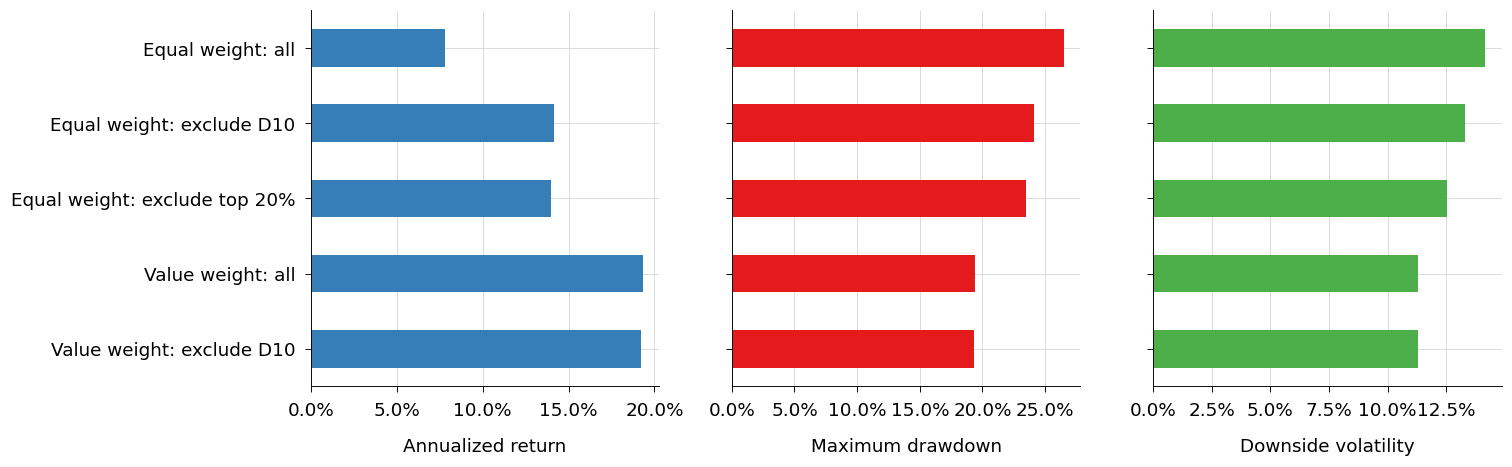

In [3]:
strategy_labels = {
    "equal_all": "Equal weight: all",
    "equal_exclude_d10": "Equal weight: exclude D10",
    "equal_exclude_top20": "Equal weight: exclude top 20%",
    "value_all": "Value weight: all",
    "value_exclude_d10": "Value weight: exclude D10",
    "dfrag_10": "DFRAG-10",
    "dfrag_20": "DFRAG-20",
}
base_strategies = ["equal_all", "equal_exclude_d10", "equal_exclude_top20", "value_all", "value_exclude_d10"]
gross = performance.loc[performance["strategy"].isin(base_strategies)].copy()
gross["Strategy"] = gross["strategy"].map(strategy_labels)
metrics = ["annualized_return", "annualized_volatility", "sharpe_ratio", "maximum_drawdown", "downside_volatility"]
formats = {column: "{:.2%}" for column in metrics if column != "sharpe_ratio"}
formats["sharpe_ratio"] = "{:.3f}"
display(gross[["Strategy", *metrics]].style.format(formats))

figure, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for axis, column, title, color in zip(
    axes,
    ["annualized_return", "maximum_drawdown", "downside_volatility"],
    ["Annualized return", "Maximum drawdown", "Downside volatility"],
    COLOR_PALETTE[:3],
    strict=True,
):
    gross.set_index("Strategy")[column].plot.barh(ax=axis, color=color)
    axis.set(xlabel=title, ylabel="")
    axis.xaxis.set_major_formatter(PercentFormatter(1))
axes[0].invert_yaxis()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "06_02_screening_and_weighting.pdf")
plt.show()

## 3. Return distributions

Weekly compounded returns retain enough observations for a readable comparison while exposing differences in the left tail.

,Mean,Volatility,5th percentile,Worst week
Equal weight: all,0.18%,2.79%,-3.86%,-9.41%
Equal weight: exclude D10,0.28%,2.63%,-3.56%,-9.34%
Equal weight: exclude top 20%,0.28%,2.47%,-3.51%,-9.03%
Value weight: all,0.36%,2.16%,-2.46%,-9.11%
Value weight: exclude D10,0.35%,2.16%,-2.46%,-9.11%


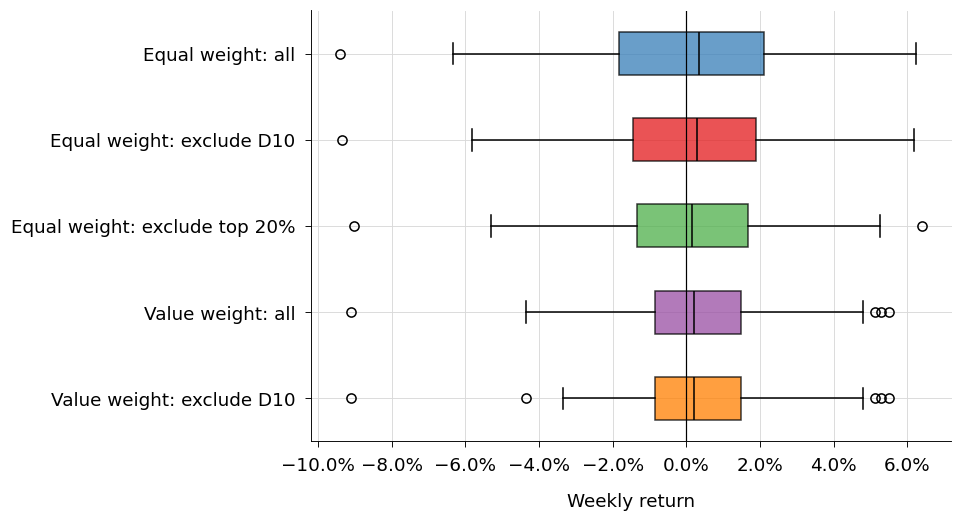

In [4]:
return_columns = [f"{strategy}_return" for strategy in base_strategies]
weekly = daily.set_index("date")[return_columns].add(1).resample("W-FRI").prod().sub(1)
weekly.columns = [strategy_labels[column.removesuffix("_return")] for column in weekly]
weekly_summary = pd.DataFrame({
    "Mean": weekly.mean(),
    "Volatility": weekly.std(ddof=1),
    "5th percentile": weekly.quantile(0.05),
    "Worst week": weekly.min(),
})
display(weekly_summary.style.format("{:.2%}"))

figure, axis = plt.subplots(figsize=(9, 5))
boxplot = axis.boxplot(
    [weekly[column].dropna() for column in weekly],
    tick_labels=weekly.columns,
    vert=False,
    patch_artist=True,
    medianprops={"color": "black"},
)
for patch, color in zip(boxplot["boxes"], COLOR_PALETTE[:5], strict=True):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axis.axvline(0, color="black", linewidth=0.8)
axis.set(xlabel="Weekly return")
axis.xaxis.set_major_formatter(PercentFormatter(1))
axis.invert_yaxis()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "06_02_weekly_return_distributions.pdf")
plt.show()

## 4. Turnover and transaction costs

Later turnover compares each new target with the previous buy-and-hold weights. Factor turnover is summed across its long and short legs and therefore ranges from zero to two. Costs are charged at each quarterly formation; borrowing and financing costs remain outside this simple sensitivity check.

,Mean later turnover
strategy,
DFRAG-20,65.05%
DFRAG-10,80.12%
Value weight: all,1.20%
Value weight: exclude D10,1.23%
Equal weight: exclude D10,12.01%
Equal weight: all,12.22%
Equal weight: exclude top 20%,11.83%


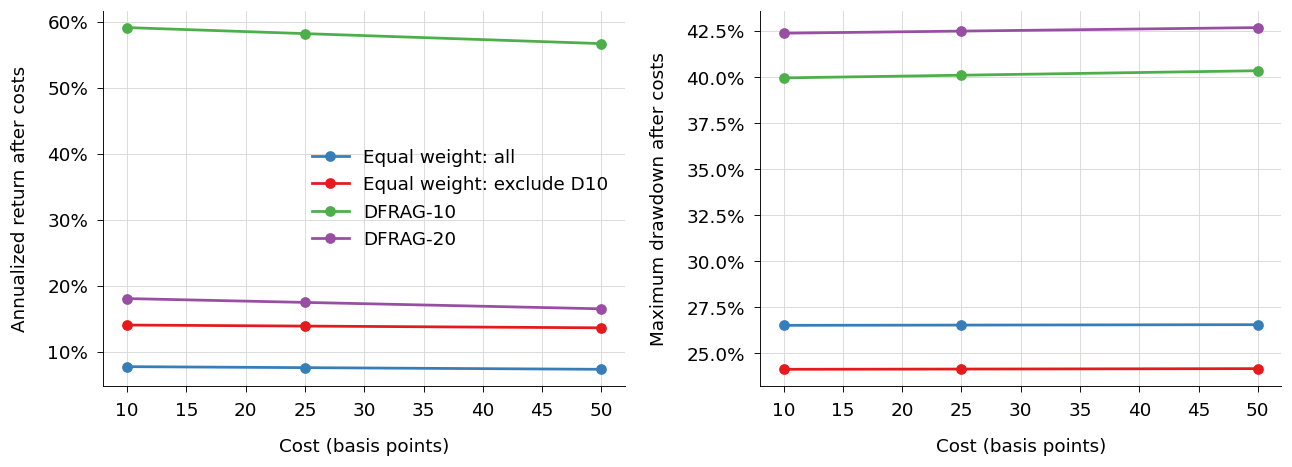

In [5]:
later_turnover = (
    turnover.sort_values("report_period")
    .groupby("strategy", sort=False).tail(report_periods - 1)
    .groupby("strategy", sort=False)["one_way_turnover"].mean()
    .rename("Mean later turnover").to_frame()
)
later_turnover.index = later_turnover.index.map(strategy_labels)
display(later_turnover.style.format("{:.2%}"))

cost_plot = costs.pivot(index="cost_bps", columns="strategy", values=["annualized_return", "maximum_drawdown"])
cost_strategies = ["equal_all", "equal_exclude_d10", "dfrag_10", "dfrag_20"]
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, metric, title in zip(axes, ["annualized_return", "maximum_drawdown"], ["Annualized return after costs", "Maximum drawdown after costs"], strict=True):
    for strategy, color in zip(cost_strategies, COLOR_PALETTE[:4], strict=True):
        axis.plot(cost_plot.index, cost_plot[(metric, strategy)], marker="o", color=color, label=strategy_labels[strategy])
    axis.set(xlabel="Cost (basis points)", ylabel=title)
    axis.yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "06_02_turnover_and_costs.pdf")
plt.show()

## 5. Active-alpha inference

Changing the HAC lag changes only the uncertainty around the primary screen's FF5-plus-momentum alpha.

In [6]:
display(alpha[["hac_lag", "annualized_alpha", "alpha_t_statistic", "alpha_p_value"]].style.format({
    "annualized_alpha": "{:.2%}",
    "alpha_t_statistic": "{:.3f}",
    "alpha_p_value": "{:.4f}",
}))

,hac_lag,annualized_alpha,alpha_t_statistic,alpha_p_value
0,5,5.47%,2.795,0.0052
1,21,5.47%,2.578,0.0099
2,63,5.47%,2.677,0.0074


## 6. Fragility-factor breadth

DFRAG-10 uses only the extreme deciles. DFRAG-20 tests whether the relation survives when each leg is broadened to two deciles. Return magnitudes are comparable because both retain 100% long and 100% short exposure. Equal-weighted and value-weighted all-stock portfolios are included as descriptive benchmarks, although their fully invested exposure differs from the zero-investment factors.

In [7]:
factor_labels = {"original": "DFRAG-10", "dfrag_20": "DFRAG-20"}
breadth_performance = factor_performance.loc[factor_performance["strategy"].isin(factor_labels)].copy()
breadth_performance["Strategy"] = breadth_performance["strategy"].map(factor_labels)
benchmark_performance = performance.loc[performance["strategy"].isin(["equal_all", "value_all"])].copy()
benchmark_performance["Strategy"] = benchmark_performance["strategy"].map(strategy_labels)
factor_comparison = pd.concat([benchmark_performance, breadth_performance], ignore_index=True)
display(factor_comparison[["Strategy", *metrics]].style.format(formats))

breadth_alpha = factor_alpha.loc[factor_alpha["strategy"].isin(factor_labels)].copy()
breadth_alpha["Strategy"] = breadth_alpha["strategy"].map(factor_labels)
display(breadth_alpha[["Strategy", "annualized_alpha", "alpha_t_statistic", "alpha_p_value", "adjusted_r_squared"]].style.format({
    "annualized_alpha": "{:.2%}",
    "alpha_t_statistic": "{:.3f}",
    "alpha_p_value": "{:.4f}",
    "adjusted_r_squared": "{:.3f}",
}))

quarterly_factors = daily.groupby("report_period", as_index=False).agg(
    **{label: (column, lambda returns: (1 + returns).prod() - 1) for label, column in factor_columns.items()}
)
display(quarterly_factors.style.format({label: "{:.1%}" for label in factor_columns}))

,Strategy,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,Equal weight: all,7.82%,20.37%,0.239,26.50%,14.14%
1,Value weight: all,19.32%,16.64%,0.861,19.39%,11.30%
2,DFRAG-10,59.76%,35.15%,1.509,39.85%,22.16%
3,DFRAG-20,18.44%,29.43%,0.721,42.30%,18.73%


,Strategy,annualized_alpha,alpha_t_statistic,alpha_p_value,adjusted_r_squared
0,DFRAG-10,56.44%,2.282,0.0225,0.389
1,DFRAG-20,24.23%,1.287,0.1982,0.508


,report_period,DFRAG-10,DFRAG-20
0,2024-03-31 00:00:00,39.7%,28.3%
1,2024-06-30 00:00:00,14.5%,6.2%
2,2024-09-30 00:00:00,-10.5%,-13.2%
3,2024-12-31 00:00:00,42.0%,21.4%
4,2025-03-31 00:00:00,-17.8%,-16.1%
5,2025-06-30 00:00:00,4.3%,-3.4%
6,2025-09-30 00:00:00,47.4%,25.9%
7,2025-12-31 00:00:00,-1.0%,-4.4%


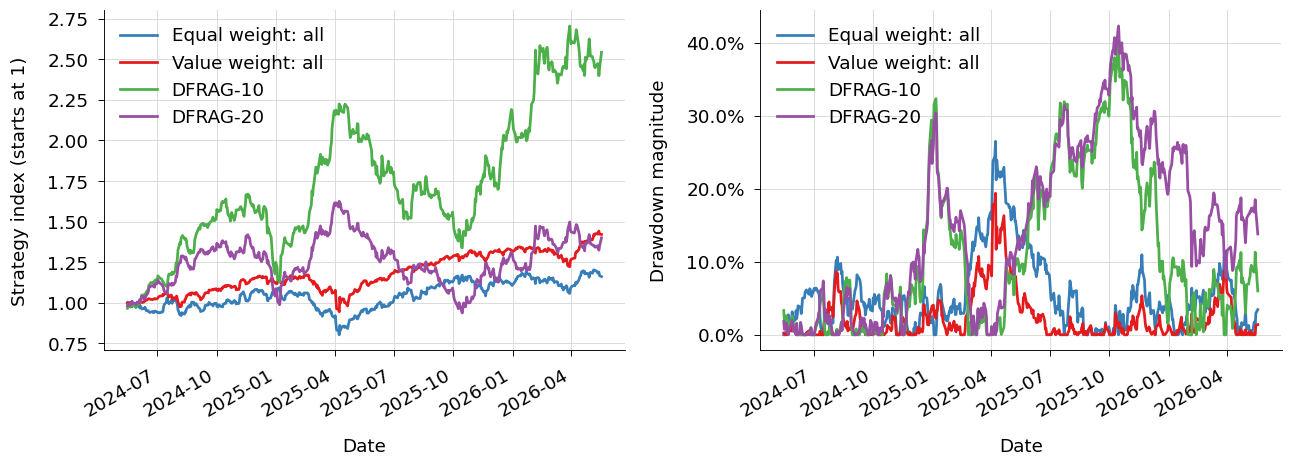

In [8]:
factor_returns = daily[list(factor_columns.values())].rename(columns={column: label for label, column in factor_columns.items()})
comparison_returns = pd.concat([
    daily[["equal_all_return", "value_all_return"]].rename(columns={"equal_all_return": "Equal weight: all", "value_all_return": "Value weight: all"}),
    factor_returns,
], axis=1)
comparison_wealth = comparison_returns.add(1).cumprod()
comparison_wealth.index = daily["date"]
comparison_drawdown = 1 - comparison_wealth / comparison_wealth.cummax().clip(lower=1)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
comparison_wealth.plot(ax=axes[0], color=COLOR_PALETTE[:4])
axes[0].set(xlabel="Date", ylabel="Strategy index (starts at 1)")
comparison_drawdown.plot(ax=axes[1], color=COLOR_PALETTE[:4])
axes[1].set(xlabel="Date", ylabel="Drawdown magnitude")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "06_02_factor_breadth_indices.pdf")
plt.show()

## 7. Post-hoc DFRAG-10 risk management

Constant half exposure reduces both DFRAG-10 legs to 50%. The volatility-managed version uses only lagged factor volatility and never exceeds the original exposure.

,Strategy,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,Original DFRAG-10,59.76%,35.15%,1.509,39.85%,22.16%
2,Constant half exposure,28.36%,17.58%,1.509,21.86%,11.08%
3,Volatility managed,29.79%,17.37%,1.588,20.10%,10.80%


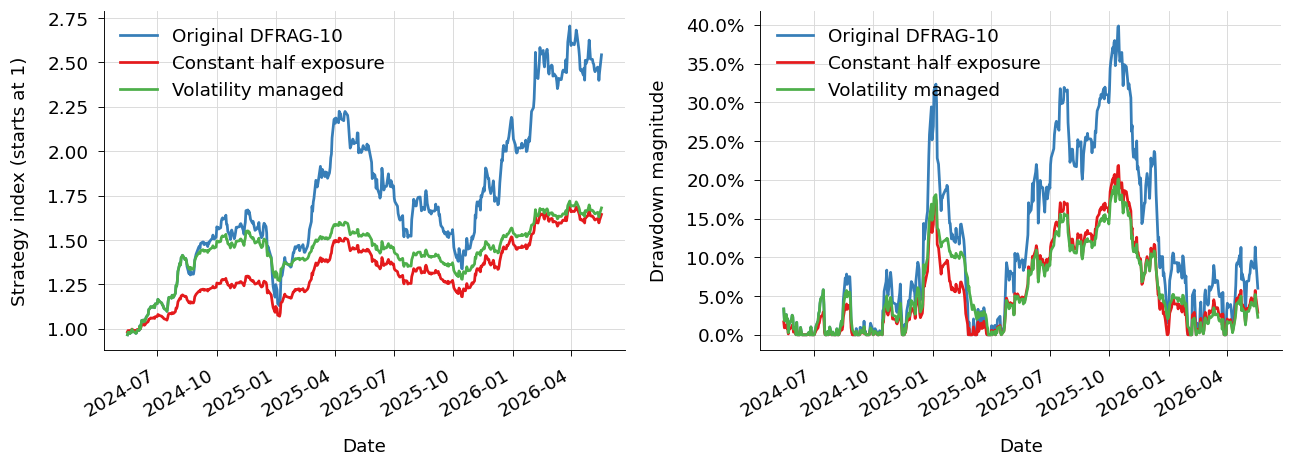

In [9]:
risk_labels = {
    "original": "Original DFRAG-10",
    "half_exposure": "Constant half exposure",
    "volatility_managed": "Volatility managed",
}
risk_performance = factor_performance.loc[factor_performance["strategy"].isin(risk_labels)].copy()
risk_performance["Strategy"] = risk_performance["strategy"].map(risk_labels)
display(risk_performance[["Strategy", *metrics]].style.format(formats))

risk_columns = {
    "Original DFRAG-10": "defensive_fragility_factor_return",
    "Constant half exposure": "half_exposure_fragility_factor_return",
    "Volatility managed": "volatility_managed_fragility_factor_return",
}
risk_wealth = daily[list(risk_columns.values())].rename(columns={column: label for label, column in risk_columns.items()}).add(1).cumprod()
risk_wealth.index = daily["date"]
risk_drawdown = 1 - risk_wealth / risk_wealth.cummax().clip(lower=1)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
risk_wealth.plot(ax=axes[0], color=COLOR_PALETTE[:3])
axes[0].set(xlabel="Date", ylabel="Strategy index (starts at 1)")
risk_drawdown.plot(ax=axes[1], color=COLOR_PALETTE[:3])
axes[1].set(xlabel="Date", ylabel="Drawdown magnitude")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "06_02_risk_managed_indices.pdf")
plt.show()

## 8. Relation to established factors

Daily correlations indicate whether either fragility spread mainly reproduces an established factor. FF5-plus-momentum alpha tests whether its average return remains after controlling for those factors.

,Market,SMB,HML,RMW,CMA,Momentum
DFRAG-10,-0.380,-0.310,0.313,0.560,0.027,-0.088
DFRAG-20,-0.402,-0.319,0.388,0.646,0.063,-0.130


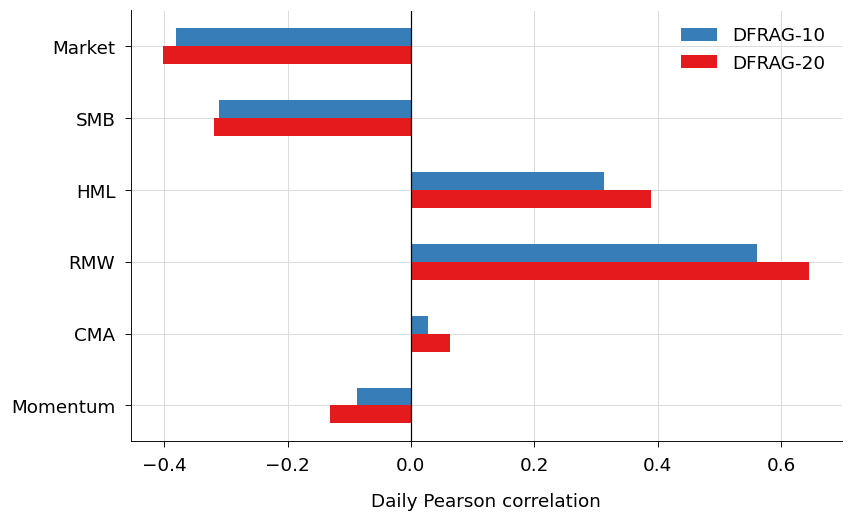

In [10]:
market_factors = ["market_excess_return", "smb", "hml", "rmw", "cma", "momentum"]
market_labels = {"market_excess_return": "Market", "smb": "SMB", "hml": "HML", "rmw": "RMW", "cma": "CMA", "momentum": "Momentum"}
factor_data = pd.concat([factor_returns.reset_index(drop=True), primary[market_factors]], axis=1)
correlations = factor_data.corr().loc[list(factor_columns), market_factors]
correlations.columns = correlations.columns.map(market_labels)
display(correlations.style.format("{:.3f}"))

correlations.T.plot.barh(figsize=(8, 5), color=COLOR_PALETTE[:2])
axis = plt.gca()
axis.axvline(0, color="black", linewidth=0.8)
axis.set(xlabel="Daily Pearson correlation", ylabel="")
axis.invert_yaxis()
apply_matplotlib_layout(axis.figure)
axis.figure.savefig(paths.figures / "06_02_factor_correlations.pdf")
plt.show()

## 9. Interpretation

The primary long-only result survives the stricter equal-weight screen: excluding D10 lowers maximum drawdown from 26.50% to 24.11%, while excluding the top 20% lowers it to 23.51%. The result does not extend materially to value weighting, suggesting that it is concentrated outside the largest stocks. The primary active FF5-plus-momentum alpha remains 5.32% annually and statistically significant across all three HAC lags.

The factor-breadth check is weaker. DFRAG-20 has lower annualized volatility than DFRAG-10 (29.67% versus 34.83%) and lower later two-leg turnover (66.19% versus 80.15%), but its annualized return falls from 58.59% to 16.08%, its Sharpe ratio falls from 1.498 to 0.650, and its maximum drawdown is slightly higher (42.53% versus 41.41%). Its FF5-plus-momentum alpha is 21.92% with $p=0.2381$, compared with 54.87% and $p=0.0223$ for DFRAG-10. DFRAG-20 is positive in four of eight quarters, while DFRAG-10 is positive in six. The spread is therefore concentrated more strongly in the extreme deciles rather than extending uniformly across the outer 20%.

At 50 basis points per unit of turnover, annualized returns remain 55.57% for DFRAG-10 and 14.15% for DFRAG-20. This check does not include short-borrowing or financing costs, so neither factor should be presented as an implementable net return. Both factors have similar standard-factor exposures; DFRAG-20 is somewhat more correlated with RMW and HML.

The post-hoc volatility-managed DFRAG-10 reduces maximum drawdown to 20.86% and volatility to 17.34%, but it is exploratory and cannot replace the original fixed specification. Overall, the evidence supports the long-only fragility screen and shows that the factor result is strongest in the extreme predicted-fragility tails. The test still covers only 502 trading days and eight quarterly formations.